# Proyecto 1 — Predicción del precio horario de la energía en Guatemala

Queremos predecir el precio de oportunidad de la energía (USD/MWh) hora por hora para 2025, usando como historia 2023 y 2024. Lo tratamos como un problema de regresión.

In [2]:
import re
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Carga, limpieza y transformación de datos


In [3]:
pd.read_excel("data/Precios2023.xls", sheet_name="POE (Anual)", header=None, nrows=6, engine="xlrd")

,0,1,2
0,Administrador del Mercado Mayorista de Guatemala,NaN,NaN
1,Precios de Oportunidad de la Energía,NaN,NaN
2,Año 2023,NaN,NaN
3,Día,hora,USD/MWH
4,2023-01-01 00:00:00,0,74.2314
5,2023-01-01 00:00:00,1,74.2314


Las primeras 3 filas son encabezado y la fila 3 trae los nombres de columna: Día, hora, USD/MWH. Por lo tanto, se ignoran estas filas y se continúa hasta encontrar la data.

In [4]:
def leer_anio(anio):
    df = pd.read_excel(f"data/Precios{anio}.xls", sheet_name="POE (Anual)",
                       skiprows=3, engine="xlrd")
    df.columns = ["fecha", "hora", "precio"]  
    df["anio"] = anio
    return df

df = pd.concat([leer_anio(a) for a in [2023, 2024, 2025]], ignore_index=True)
print(df.shape)
df.head()

(26304, 4)


,fecha,hora,precio,anio
0,2023-01-01,0,74.2314,2023
1,2023-01-01,1,74.2314,2023
2,2023-01-01,2,59.0752,2023
3,2023-01-01,3,59.0752,2023
4,2023-01-01,4,80.9615,2023


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   26304 non-null  datetime64[ns]
 1   hora    26304 non-null  int64         
 2   precio  26304 non-null  object        
 3   anio    26304 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 822.1+ KB


La fecha ya viene como datetime, bien. Pero el precio salió como object en vez de número, o sea que hay texto metido en esa columna. Se debe buscar que provoca que no sea el datatype correcto.

In [6]:
malos = df[pd.to_numeric(df["precio"], errors="coerce").isna()]
malos[["anio", "fecha", "hora", "precio"]]

,anio,fecha,hora,precio
2777,2023,2023-04-26,17,167.9951l
6632,2023,2023-10-04,8,104.2607'
6786,2023,2023-10-10,18,142.0377s
7043,2023,2023-10-21,11,156.9681a
8942,2024,2024-01-08,14,d
9097,2024,2024-01-15,1,69.038.0
14217,2024,2024-08-15,9,86.6421p
17638,2025,2025-01-04,22,2.1302.wq
17720,2025,2025-01-08,8,87.5625.3


In [7]:
def a_numero(x):
    if isinstance(x, (int, float)):
        return float(x)
    s = re.sub(r"[^0-9.]", "", str(x))      
    if s.count(".") > 1:                     
        p = s.find(".")
        s = s[:p+1] + s[p+1:].replace(".", "")
    return float(s) if s not in ("", ".") else np.nan

df["precio"] = df["precio"].apply(a_numero)
print("precios que quedaron como NaN:", df["precio"].isna().sum())   

precios que quedaron como NaN: 1


In [8]:
sorted(df["hora"].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(220),
 np.int64(230),
 np.int64(2300)]

Aparecen 220, 230 y 2300, que no son horas válidas. Se necesita unicamente remover esos valores y reemplazarlos por los correctos.

In [9]:
df["hora"] = df["hora"].replace({220: 22, 230: 23, 2300: 23})
sorted(df["hora"].unique())   

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

armo la columna de fecha y hora, y recolecto información necesaria para el análisis como mes, día de la semana, si es fin de semana.

In [10]:
df["datetime"] = df["fecha"] + pd.to_timedelta(df["hora"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

df["mes"] = df["datetime"].dt.month
df["dia_sem"] = df["datetime"].dt.dayofweek   
df["finde"] = df["dia_sem"] >= 5
df.head()

,fecha,hora,precio,anio,datetime,mes,dia_sem,finde
0,2023-01-01,0,74.2314,2023,2023-01-01 00:00:00,1,6,True
1,2023-01-01,1,74.2314,2023,2023-01-01 01:00:00,1,6,True
2,2023-01-01,2,59.0752,2023,2023-01-01 02:00:00,1,6,True
3,2023-01-01,3,59.0752,2023,2023-01-01 03:00:00,1,6,True
4,2023-01-01,4,80.9615,2023,2023-01-01 04:00:00,1,6,True


interpolo el número faltante que tiene la letra d usando un promedio con el número anterior y el número siguiente. 

In [11]:
print(df[df["precio"].isna()][["fecha", "hora", "precio"]])
df["precio"] = df["precio"].interpolate()
print("faltantes despues:", df["precio"].isna().sum())

          fecha  hora  precio
8942 2024-01-08    14     NaN
faltantes despues: 0


In [12]:
dias = df.groupby("fecha").size()
print("dias que NO tienen 24 horas:", (dias != 24).sum())
print("filas duplicadas (misma fecha y hora):", df.duplicated(["fecha", "hora"]).sum())


print(df.groupby("anio").size())

dias que NO tienen 24 horas: 0
filas duplicadas (misma fecha y hora): 0
anio
2023    8760
2024    8784
2025    8760
dtype: int64


### División de los datos

Les puse etiqueta a los datasets de entrenamiento y 2025 como prueba y no para entrenar.

In [13]:
train = df[df["anio"] < 2025].copy()
test_2025 = df[df["anio"] == 2025].copy()
print("entrenamiento (2023-2024):", len(train))
print("prueba (2025, reservado):", len(test_2025))

entrenamiento (2023-2024): 17544
prueba (2025, reservado): 8760


## 2. Análisis exploratorio del mercado

Descripción estadística de los precios.

In [14]:
train["precio"].describe().round(2)

count      17544.00
mean         284.21
std        12320.15
min            0.63
25%           76.43
50%          101.56
75%          132.10
max      1376899.00
Name: precio, dtype: float64

La media (284) está bastante por encima de la mediana (101.56) y el máximo supera el millón, así que hay unos valores altos que suben el promedio.

Para describir los patrones uso la mediana en lugar de la media, porque es menos sensible a esos valores extremos. Con la media, un outlier extremo en una hora bastaría para inflar el promedio de esa hora.

### Cómo evoluciona el precio en el tiempo

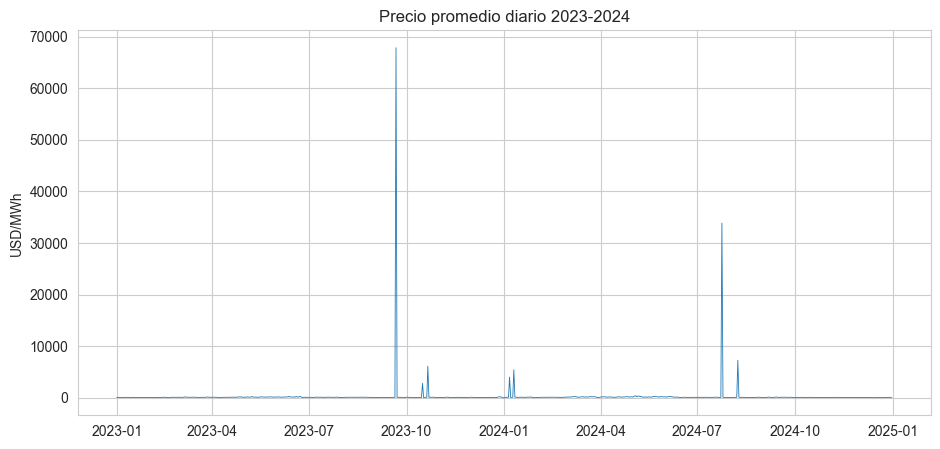

In [15]:
# precio promedio por dia
diario = train.set_index("datetime")["precio"].resample("D").mean()
plt.plot(diario.index, diario.values, lw=0.6)
plt.title("Precio promedio diario 2023-2024")
plt.ylabel("USD/MWh")
plt.show()

Como se puede observar, los picos mencionados alteran el promedio diario.

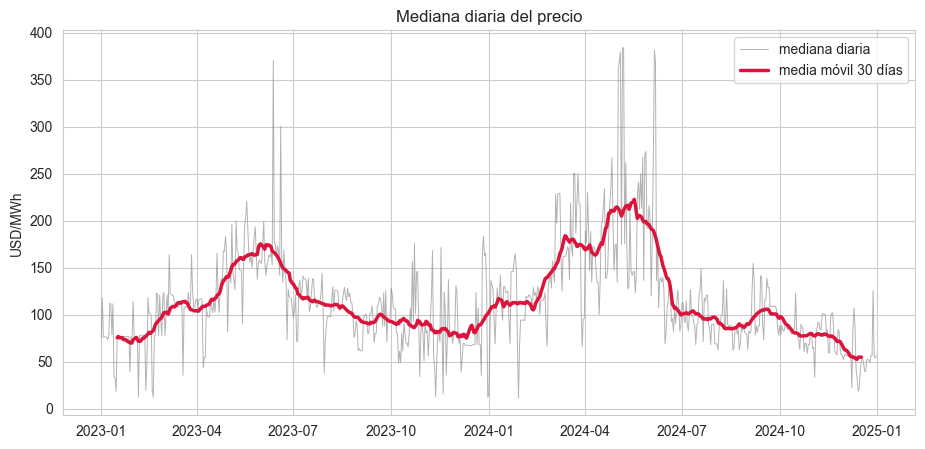

In [16]:
diario_med = train.set_index("datetime")["precio"].resample("D").median()
plt.plot(diario_med.index, diario_med.values, lw=0.7, color="gray", alpha=0.6, label="mediana diaria")
plt.plot(diario_med.index, diario_med.rolling(30, center=True).mean(), lw=2.5, color="crimson", label="media móvil 30 días")
plt.title("Mediana diaria del precio")
plt.ylabel("USD/MWh")
plt.legend()
plt.show()

Con la mediana se distingue mejor la forma. El precio sube entre marzo y junio y baja en la segunda mitad del año, así que parece tener un componente estacional. Se ve más claro en el gráfico por mes.

### Patrón por hora del día

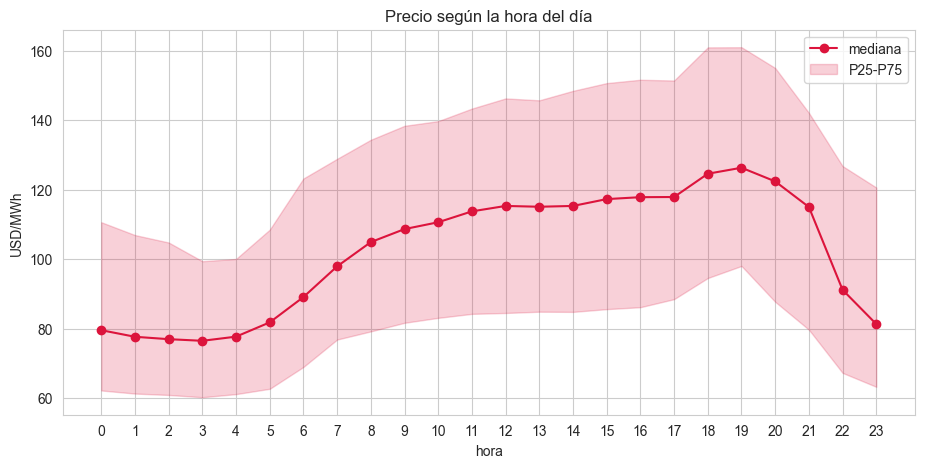

hora más barata: 3 | hora más cara: 19


In [17]:
por_hora = train.groupby("hora")["precio"].median()
q25 = train.groupby("hora")["precio"].quantile(0.25)
q75 = train.groupby("hora")["precio"].quantile(0.75)

plt.plot(por_hora.index, por_hora.values, "o-", color="crimson", label="mediana")
plt.fill_between(por_hora.index, q25, q75, alpha=0.2, color="crimson", label="P25-P75")
plt.xticks(range(24))
plt.xlabel("hora"); plt.ylabel("USD/MWh")
plt.title("Precio según la hora del día")
plt.legend()
plt.show()

print("hora más barata:", por_hora.idxmin(), "| hora más cara:", por_hora.idxmax())

El precio es más bajo de madrugada y alcanza su punto más alto en la tarde/noche. En las horas pico el área de P25-P75 también es más ancha, es decir que hay más variación de precio en esas horas.

### Patrón por día de la semana

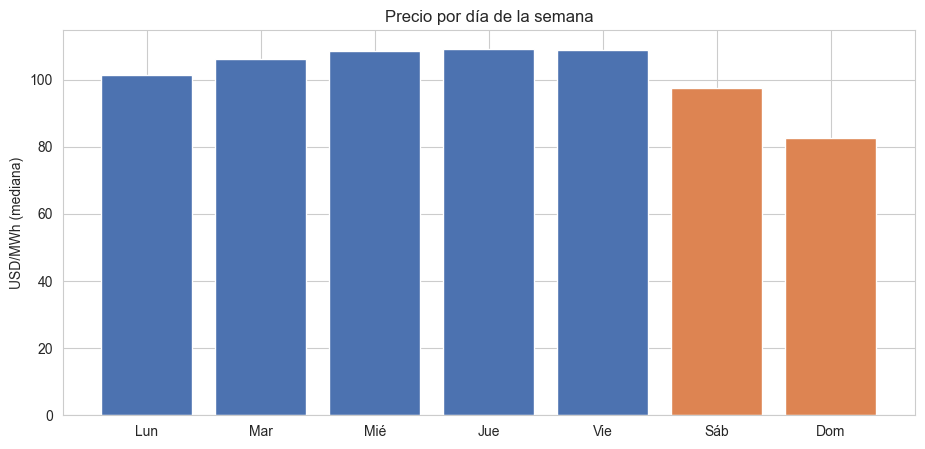

laboral: 108.2 | fin de semana: 89.4


In [18]:
dias_nom = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dia = train.groupby("dia_sem")["precio"].median()

colores = ["#4C72B0"]*5 + ["#DD8452"]*2
plt.bar([dias_nom[i] for i in por_dia.index], por_dia.values, color=colores)
plt.ylabel("USD/MWh (mediana)")
plt.title("Precio por día de la semana")
plt.show()

print("laboral:", round(train[~train["finde"]]["precio"].median(), 1),
      "| fin de semana:", round(train[train["finde"]]["precio"].median(), 1))

Los días de semana son más caros que el fin de semana, y el domingo es el más barato. Probablemente porque el sábado y el domingo baja la actividad industrial y comercial.

### Patrón por mes

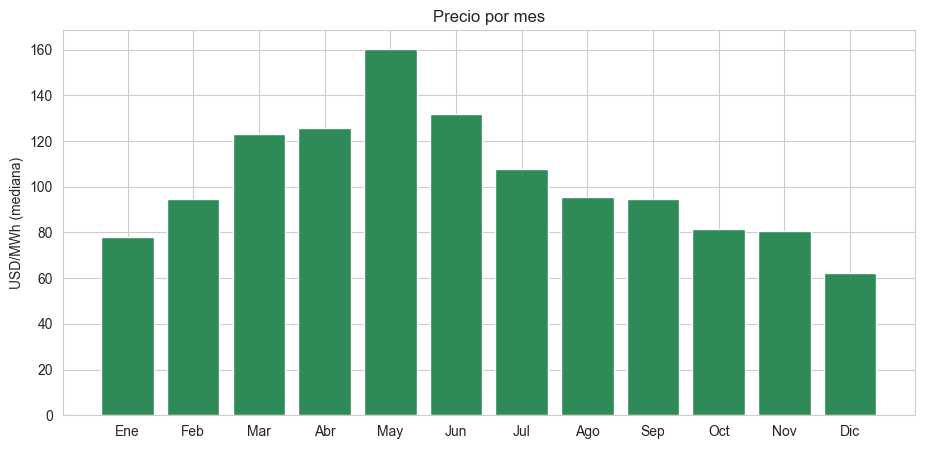

In [19]:
meses_nom = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
por_mes = train.groupby("mes")["precio"].median()

plt.bar([meses_nom[m-1] for m in por_mes.index], por_mes.values, color="seagreen")
plt.ylabel("USD/MWh (mediana)")
plt.title("Precio por mes")
plt.show()

El patrón mensual es el más marcado de los tres. De marzo a junio el precio es más alto (mayo siendo el más alto) y de julio en adelante baja, con diciembre como el mes más barato.

Esto encaja con que Guatemala depende bastante de la generación hidroeléctrica, ya que en época seca se reduce la generación de energía hidroeléctrica y el precio sube. Cuando empiezan las lluvias hay más generación, que es más barata, y el precio baja.

### Comparación entre 2023 y 2024

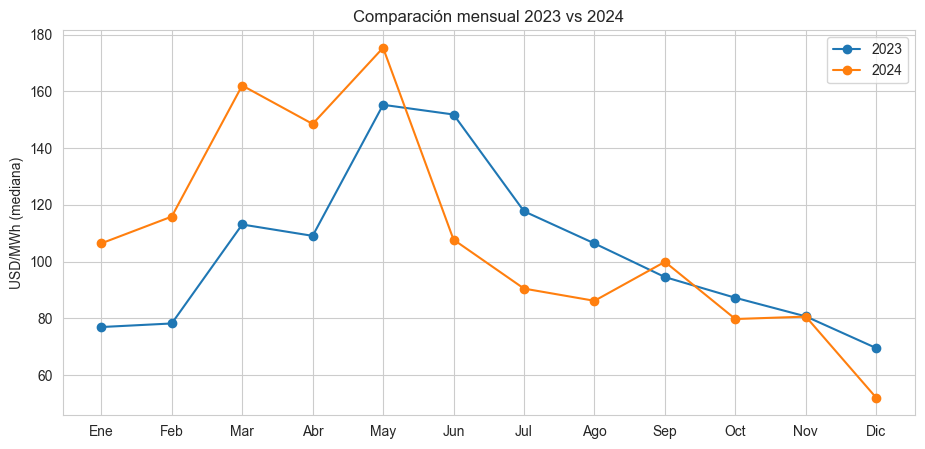

2023: mediana=104.9  máx=1376899
2024: mediana=96.4  máx=810402


In [20]:
comp = train.groupby(["anio", "mes"])["precio"].median().unstack("anio")
for a in [2023, 2024]:
    plt.plot(comp.index, comp[a], "o-", label=str(a))
plt.xticks(range(1, 13), meses_nom)
plt.ylabel("USD/MWh (mediana)")
plt.title("Comparación mensual 2023 vs 2024")
plt.legend()
plt.show()

for a in [2023, 2024]:
    s = train[train["anio"] == a]["precio"]
    print(f"{a}: mediana={s.median():.1f}  máx={s.max():.0f}")

La forma se repite en los dos años (sube en seca, baja en lluvia), lo cual conviene porque indica que hay un patrón estable que el modelo puede aprender. El nivel, en cambio, no es igual entre un año y otro. Esto sugiere que el calendario sirve para explicar la forma del precio, pero el nivel de cada año depende de factores que no están en los datos, como cuánto llovió o el precio de los combustibles.

### La distribución y los valores extremos

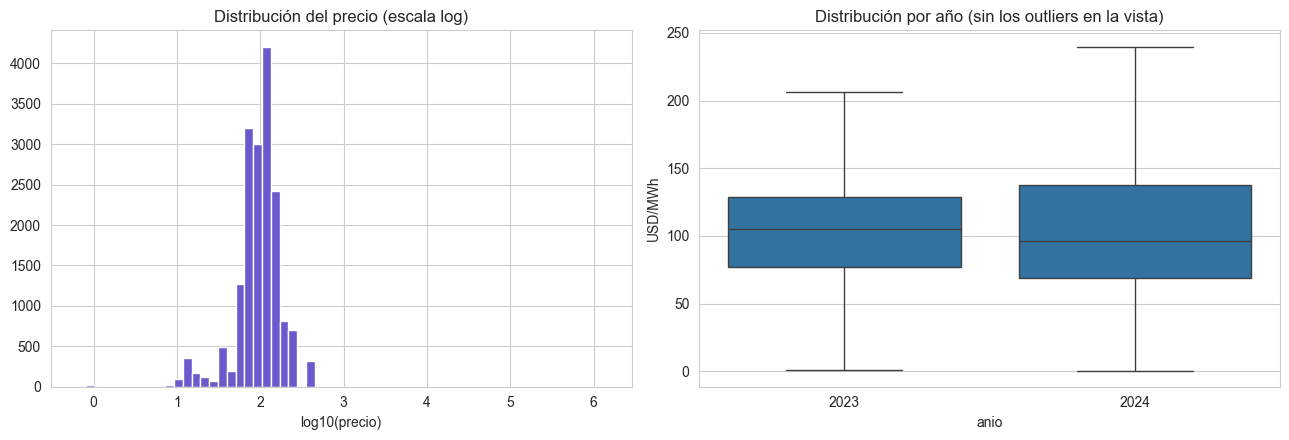

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(np.log10(train["precio"].clip(lower=0.1)), bins=60, color="slateblue", edgecolor="white")
ax[0].set_xlabel("log10(precio)")
ax[0].set_title("Distribución del precio (escala log)")

sns.boxplot(data=train, x="anio", y="precio", showfliers=False, ax=ax[1])
ax[1].set_title("Distribución por año (sin los outliers en la vista)")
ax[1].set_ylabel("USD/MWh")
plt.tight_layout()
plt.show()

In [22]:
# los precios mas altos
train.nlargest(8, "precio")[["datetime", "hora", "precio"]]

,datetime,hora,precio
6329,2023-09-21 17:00:00,17,1376899.0
13703,2024-07-24 23:00:00,23,810402.0
14060,2024-08-08 20:00:00,20,172419.0
7042,2023-10-21 10:00:00,10,144388.0
6330,2023-09-21 18:00:00,18,131859.0
8996,2024-01-10 20:00:00,20,127788.0
6328,2023-09-21 16:00:00,16,117357.0
8892,2024-01-06 12:00:00,12,94444.0


La distribución está concentrada en valores bajos y tiene una cola larga hacia la derecha. Los 8 valores de arriba son mucho mayores que el resto y casi todos caen entre septiembre y octubre de 2023.

Estos valores se conservan en lugar de eliminarlos. Son precios reales que reflejan situaciones de escasez de generación. El efecto de los picos se controla en la etapa de modelado transformando el precio con log y usando el error absoluto medio (MAE) como métrica, ya que es menos sensible a los outliers.

### Mapas de calor: hora cruzada con mes y con día

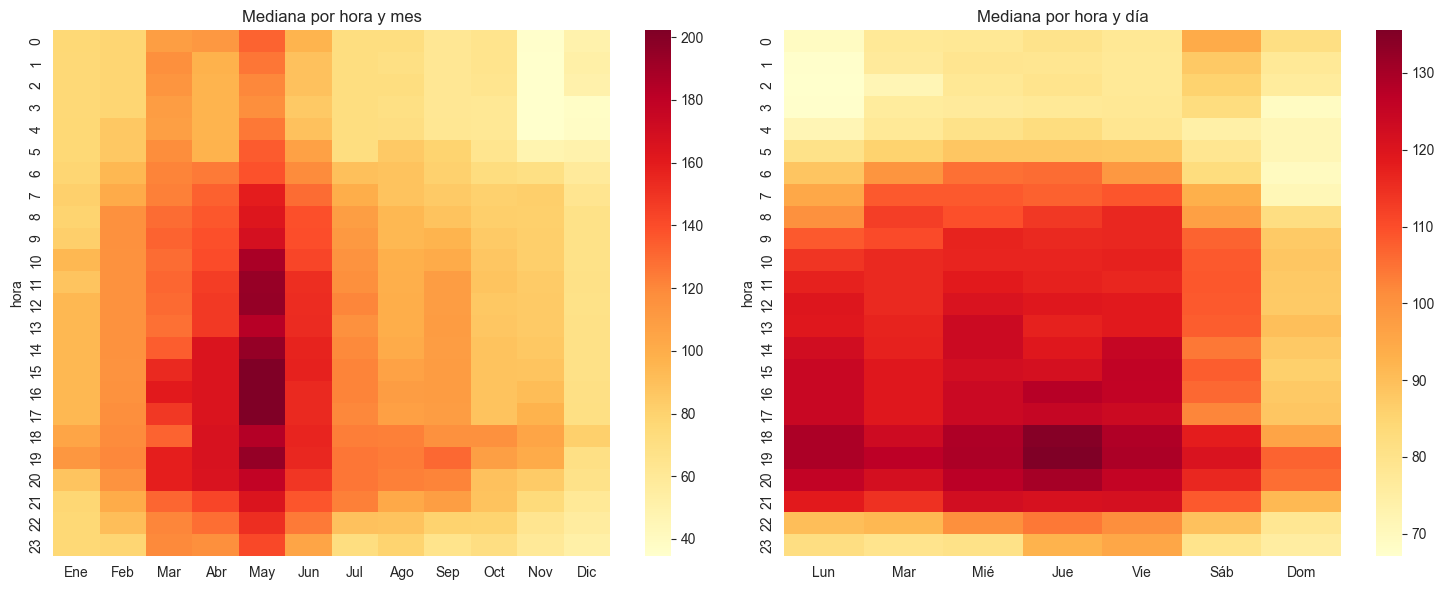

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

piv1 = train.pivot_table(index="hora", columns="mes", values="precio", aggfunc="median")
piv1.columns = [meses_nom[m-1] for m in piv1.columns]
sns.heatmap(piv1, cmap="YlOrRd", ax=ax[0])
ax[0].set_title("Mediana por hora y mes")

piv2 = train.pivot_table(index="hora", columns="dia_sem", values="precio", aggfunc="median")
piv2.columns = [dias_nom[d] for d in piv2.columns]
sns.heatmap(piv2, cmap="YlOrRd", ax=ax[1])
ax[1].set_title("Mediana por hora y día")
plt.tight_layout()
plt.show()

El primer mapa muestra que los precios más altos se dan en la tarde/noche durante la epoca seca. El segundo muestra que el patrón horario se mantiene en todos los días, aunque algo más suave el fin de semana. Entre los dos, el mes influye más en el precio que el día de la semana.

### Horas valle, intermedias y pico

Para resumir el patrón horario, las horas se agrupan en tres categorías según su precio mediano: el tercio más barato son horas valle, el del medio intermedias y el tercio más caro horas pico. 

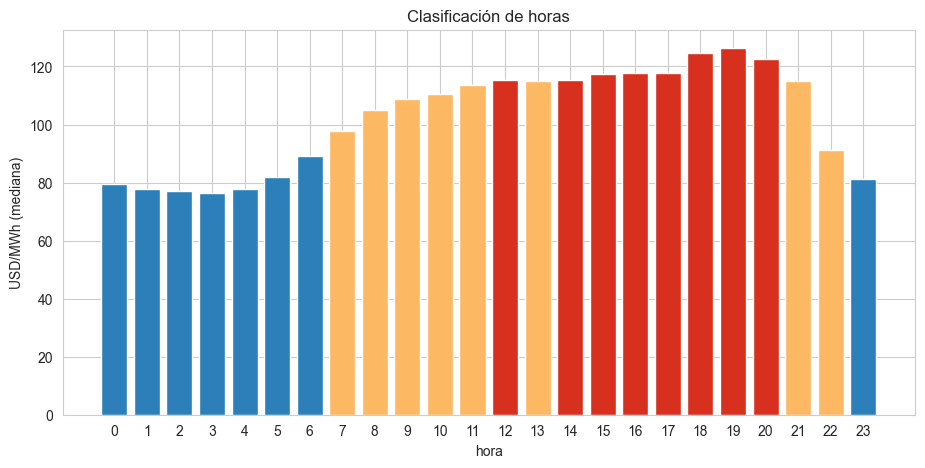

valle -> [0, 1, 2, 3, 4, 5, 6, 23]
intermedia -> [7, 8, 9, 10, 11, 13, 21, 22]
pico -> [12, 14, 15, 16, 17, 18, 19, 20]


In [25]:
mediana_hora = train.groupby("hora")["precio"].median()
c1, c2 = mediana_hora.quantile([1/3, 2/3])

def clasificar(p):
    if p <= c1: return "valle"
    if p <= c2: return "intermedia"
    return "pico"

grupo_hora = mediana_hora.apply(clasificar)

colores_g = {"valle": "#2C7FB8", "intermedia": "#FDB863", "pico": "#D7301F"}
plt.bar(mediana_hora.index, mediana_hora.values,
        color=[colores_g[grupo_hora[h]] for h in mediana_hora.index])
plt.xticks(range(24)); plt.xlabel("hora"); plt.ylabel("USD/MWh (mediana)")
plt.title("Clasificación de horas")
plt.show()

for g in ["valle", "intermedia", "pico"]:
    print(g, "->", sorted(grupo_hora[grupo_hora == g].index.tolist()))

Quedan tres bloques: las horas valle son la madrugada y las horas tarde de la noche, las pico son el mediodía y la tarde/noche, y las intermedias quedan en la transición. 